### Libraries

In [193]:
import pyreadstat
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import chi2
from scipy.stats import chi2_contingency
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
from mpl_toolkits.mplot3d import Axes3D
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
import geopandas as gpd
from imblearn.pipeline import Pipeline

## Load data

In [194]:
df_ch = pd.read_spss('/workspaces/malnutrition/Dataset/ch.sav')
df_ch.head(2)

,HH1,HH2,LN,UF1,UF2,UF3,UFINT,UF4,UF5,UF6,...,wscoreu,windex5u,windex10u,wscorer,windex5r,windex10r,ListCat,PSU,dstratum,stratum
0,1.0,3.0,5.0,1.0,3.0,5.0,103.0,4.0,103.0,100.0,...,NaN,NaN,NaN,-0.831559,Second,3rd decile,With child U5 during listing,1.0,"U5 HH, Province 1 Rural",Province 1 Rural
1,1.0,5.0,5.0,1.0,5.0,5.0,104.0,2.0,104.0,100.0,...,NaN,NaN,NaN,-1.220021,Poorest,2nd decile,With child U5 during listing,1.0,"U5 HH, Province 1 Rural",Province 1 Rural


In [195]:
df_ch[['AN4', 'CAGE']].isna().sum()

AN4     91
CAGE    91
dtype: int64

In [196]:
# Rename columns
feature_coded = df_ch[['EC3A', 'EC3B', 'EC9', 'UCD2A', 'UCD2B', 'UCD2C', 'UCF4', 'BD2', 'BD3', 'IM2', 'cdisability', 'BD9', 'AN4', 'CA1', 'CA14', 'HH6', 'HL4', 
                       'melevel1', 'cinsurance', 'HH7c', 'windex5', 'WAZ2', 'HAZ2', 'WHZ2', 'CA31', 'CA16']]
df = feature_coded.rename(columns={
    'EC3A': 'left alone',
    'EC3B': 'left child',
    'EC9': 'pick up',
    'UCD2A': 'away privileges',
    'UCD2B': 'explain behaviour',
    'UCD2C': 'shook',
    'UCF4': 'walking asst',
    'BD2': 'ever breastfed',
    'BD3': 'still breastfed',
    'IM2': 'vacc card',
    'cdisability': 'disability stauts',
    'BD9': 'meal freq',

    'AN4': 'child age',
    'CA1': 'diarrhoea',
    'CA14': 'fever',
    'HH6': 'area',
    'HL4': 'child sex',
    'melevel1': 'mother education',
    'cinsurance': 'health insurance',
    'HH7c': 'province',
    'windex5': 'wealth index',
    'WAZ2': 'underweight',
    'HAZ2': 'stunting',
    'WHZ2': 'wasting',
    'CA31': 'stool disposal',
    'CA16': 'cough'
})
df.head(2)

,left alone,left child,pick up,away privileges,explain behaviour,shook,walking asst,ever breastfed,still breastfed,vacc card,...,child sex,mother education,health insurance,province,wealth index,underweight,stunting,wasting,stool disposal,cough
0,NONE,NONE,NaN,NO,NO,NO,NaN,YES,YES,"YES, HAS ONLY CARD(S)",...,MALE,Secondary (Gr 9-12),Without insurance,Province 1,Poorest,-2.94,-3.53,-1.69,PUT / RINSED INTO: TOILET OR LATRINE,NO
1,NONE,NONE,YES,NO,YES,YES,YES,NaN,NaN,NaN,...,MALE,Secondary (Gr 9-12),Without insurance,Province 1,Poorest,-1.93,-2.58,-0.65,NaN,YES


In [197]:
# Value counts for each column
for col in df.columns:
    print(f"="*20)
    print(df[col].value_counts())

left alone
NONE           5208
7.0             542
2.0             263
1.0             164
3.0             145
4.0             118
5.0             116
6.0              58
DK               39
NO RESPONSE       5
Name: count, dtype: int64
left child
NONE           5493
7.0             281
2.0             266
1.0             218
3.0             137
5.0             108
4.0              81
DK               36
6.0              35
NO RESPONSE       3
Name: count, dtype: int64
pick up
YES    2707
NO      177
DK       14
Name: count, dtype: int64
away privileges
NO             3361
YES            2147
NO RESPONSE       9
Name: count, dtype: int64
explain behaviour
YES            4332
NO             1183
NO RESPONSE       2
Name: count, dtype: int64
shook
NO             3551
YES            1963
NO RESPONSE       3
Name: count, dtype: int64
walking asst
NO             4007
YES             188
NO RESPONSE       1
Name: count, dtype: int64
ever breastfed
YES            3491
NO              268
NO R

In [198]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6749 entries, 0 to 6748
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   left alone         6658 non-null   category
 1   left child         6658 non-null   category
 2   pick up            2898 non-null   category
 3   away privileges    5517 non-null   category
 4   explain behaviour  5517 non-null   category
 5   shook              5517 non-null   category
 6   walking asst       4196 non-null   category
 7   ever breastfed     3760 non-null   category
 8   still breastfed    3491 non-null   category
 9   vacc card          3760 non-null   category
 10  disability stauts  4196 non-null   category
 11  meal freq          2462 non-null   category
 12  child age          6658 non-null   float64 
 13  diarrhoea          6658 non-null   category
 14  fever              6658 non-null   category
 15  area               6749 non-null   category
 16  child 

In [199]:
# Replace missing indicators with NaN
invalid_values = ['DK', 'NO RESPONSE', 'Missing/DK', 'Z-score out of range', 'Measurement out of range', ' Measurement out of range', 'Not measured']
df = df.replace(invalid_values, np.nan)

# Create binary target (stunting - most common)
df['status'] = (df['stunting'].astype(str).str.strip().astype(float) < -2).astype(int)

# Convert all categorical to string
for col in df.select_dtypes(include=['category']).columns:
    df[col] = df[col].astype(str)

# Drop target columns
# df = df.drop(columns=['stunting', 'underweight', 'wasting'])

/tmp/ipykernel_12529/3653513917.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df = df.replace(invalid_values, np.nan)
/tmp/ipykernel_12529/3653513917.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(invalid_values, np.nan)
/tmp/ipykernel_12529/3653513917.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df = d

In [200]:
# 5. Binary mappings
binary_map = {'YES': 1, 'NO': 0}
binary_cols = ['diarrhoea', 'fever', 'cough', 'ever breastfed', 
               'still breastfed', 'pick up', 'away privileges',
               'explain behaviour', 'shook', 'walking asst']
for col in binary_cols:
    df[col] = df[col].map(binary_map)

df['health insurance'] = df['health insurance'].map({'With insurance': 1, 'Without insurance': 0})
df['disability stauts'] = df['disability stauts'].map({'Has functional difficulty': 1, 'Has no functional difficulty': 0})
df['area'] = df['area'].map({'URBAN': 1, 'RURAL': 0})
df['child sex'] = df['child sex'].map({'MALE': 1, 'FEMALE': 0})

# 6. Ordinal mappings
df['mother education'] = df['mother education'].map({'None': 0, 'Basic (Gr 1-8)': 1, 'Secondary (Gr 9-12)': 2, 'Higher': 3})
df['wealth index'] = df['wealth index'].map({'Poorest': 1, 'Second': 2, 'Middle': 3, 'Fourth': 4, 'Richest': 5, '0.0': np.nan})

# Convert vacc card to binary (has card = 1, no card = 0)
df['vacc card'] = df['vacc card'].apply(
    lambda x: 1 if 'YES' in str(x) else (0 if 'NO' in str(x) else np.nan)
)

# Convert stool disposal to binary (safe = 1, unsafe = 0)
safe_disposal = ['PUT / RINSED INTO: TOILET OR LATRINE', 
                 'CHILD USED TOILET / LATRINE', 'BURIED']
df['stool disposal'] = df['stool disposal'].apply(
    lambda x: 1 if x in safe_disposal else (0 if pd.notna(x) else np.nan)
)

# Handle meal freq '7+' 
df['meal freq'] = df['meal freq'].replace('7+', 7).astype(float)

# One-hot encode province
df = pd.get_dummies(df, columns=['province'], drop_first=True, dtype=int)

# Drop outcome variables (keep status)
df = df.drop(columns=['stunting', 'underweight', 'wasting'])


In [201]:
# Value counts for each column
for col in df.columns:
    print(f"="*20)
    print(df[col].value_counts())

left alone
NONE    5208
7.0      542
2.0      263
1.0      164
3.0      145
nan      135
4.0      118
5.0      116
6.0       58
Name: count, dtype: int64
left child
NONE    5493
7.0      281
2.0      266
1.0      218
3.0      137
nan      130
5.0      108
4.0       81
6.0       35
Name: count, dtype: int64
pick up
1.0    2707
0.0     177
Name: count, dtype: int64
away privileges
0.0    3361
1.0    2147
Name: count, dtype: int64
explain behaviour
1.0    4332
0.0    1183
Name: count, dtype: int64
shook
0.0    3551
1.0    1963
Name: count, dtype: int64
walking asst
0.0    4007
1.0     188
Name: count, dtype: int64
ever breastfed
1.0    3491
0.0     268
Name: count, dtype: int64
still breastfed
1.0    3211
0.0     280
Name: count, dtype: int64
vacc card
1.0    2671
0.0    1085
Name: count, dtype: int64
disability stauts
0.0    4118
1.0      78
Name: count, dtype: int64
meal freq
0.0    587
3.0    548
2.0    431
4.0    428
5.0    213
6.0    104
1.0     99
7.0     35
Name: count, dtype: int6

In [202]:
df.isna().sum()

left alone                            0
left child                            0
pick up                            3865
away privileges                    1241
explain behaviour                  1234
shook                              1235
walking asst                       2554
ever breastfed                     2990
still breastfed                    3258
vacc card                          2993
disability stauts                  2553
meal freq                          4304
child age                            91
diarrhoea                           107
fever                                97
area                                  0
child sex                             0
mother education                     94
health insurance                     94
wealth index                         91
stool disposal                        0
cough                                95
status                                0
province_Gandaki Province             0
province_Karnali Province             0


## Handeling missing entries

In [203]:
# 1. High-missing categorical (skip-pattern / MNAR)
high_missing_cat = [
    'pick up', 'away privileges', 'explain behaviour', 'shook',
    'walking asst', 'ever breastfed', 'still breastfed',
    'vacc card', 'disability stauts'
]

# 2. Meal frequency (special handling)
meal_freq_col = 'meal freq'

# 3. Low-missing ordinal / numeric
ordinal_median = [
    'child age', 'mother education', 'wealth index'
]

# 4. Low-missing binary
binary_mode = [
    'diarrhoea', 'fever', 'cough', 'health insurance'
]

# 5. No-missing / already clean (kept as-is)
no_missing = [
    'left alone', 'left child', 'area', 'child sex',
    'stool disposal', 'status'
]

# Province dummies already clean
province_cols = [
    'province_Gandaki Province',
    'province_Karnali Province',
    'province_Province 1',
    'province_Province 2',
    'province_Province 5',
    'province_Sudoorpaschim Province'
]


In [204]:
for col in high_missing_cat:
    df[col] = df[col].astype('category')
    df[col] = df[col].cat.add_categories('Not_Asked')
    df[col] = df[col].fillna('Not_Asked')


In [205]:

# Missing indicator
df['meal_freq_missing'] = df[meal_freq_col].isna().astype(int)
# Median imputation
df[meal_freq_col] = df[meal_freq_col].fillna(df[meal_freq_col].median())


In [206]:
for col in ordinal_median:
    df[col] = df[col].fillna(df[col].median())


In [207]:
for col in binary_mode:
    df[col] = df[col].fillna(df[col].mode()[0])


In [211]:
for col in ['left alone', 'left child']:
    df[col] = df[col].replace('nan', 'Not_Asked')


In [213]:
nominal_cat = [
    'left alone', 'left child',
    'pick up', 'away privileges',
    'explain behaviour', 'shook',
    'walking asst', 'ever breastfed',
    'still breastfed', 'vacc card',
    'disability stauts'
]

for col in nominal_cat:
    df[col] = df[col].astype('category')


In [215]:
target = 'status'

categorical_cols = [
    'left alone', 'left child',
    'pick up', 'away privileges',
    'explain behaviour', 'shook',
    'walking asst', 'ever breastfed',
    'still breastfed', 'vacc card',
    'disability stauts'
]

numeric_cols = [
    'meal freq', 'meal_freq_missing',
    'child age', 'mother education',
    'wealth index'
]

binary_cols = [
    'diarrhoea', 'fever', 'cough',
    'health insurance', 'area',
    'child sex', 'stool disposal'
]

province_cols = [
    'province_Gandaki Province',
    'province_Karnali Province',
    'province_Province 1',
    'province_Province 2',
    'province_Province 5',
    'province_Sudoorpaschim Province'
]

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

X = df.drop(columns=[target])
y = df[target]

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'),
         categorical_cols),
        ('num', 'passthrough', numeric_cols + binary_cols + province_cols)
    ]
)

pipe = Pipeline([
    ('prep', preprocess),
    ('lr', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='liblinear'
    ))
])


In [209]:
df['pick up'].value_counts()

pick up
Not_Asked    3865
1.0          2707
0.0           177
Name: count, dtype: int64

In [216]:
# Value counts for each column
for col in df.columns:
    print(f"="*20)
    print(df[col].value_counts())

left alone
NONE         5208
7.0           542
2.0           263
1.0           164
3.0           145
Not_Asked     135
4.0           118
5.0           116
6.0            58
Name: count, dtype: int64
left child
NONE         5493
7.0           281
2.0           266
1.0           218
3.0           137
Not_Asked     130
5.0           108
4.0            81
6.0            35
Name: count, dtype: int64
pick up
Not_Asked    3865
1.0          2707
0.0           177
Name: count, dtype: int64
away privileges
0.0          3361
1.0          2147
Not_Asked    1241
Name: count, dtype: int64
explain behaviour
1.0          4332
Not_Asked    1234
0.0          1183
Name: count, dtype: int64
shook
0.0          3551
1.0          1963
Not_Asked    1235
Name: count, dtype: int64
walking asst
0.0          4007
Not_Asked    2554
1.0           188
Name: count, dtype: int64
ever breastfed
1.0          3491
Not_Asked    2990
0.0           268
Name: count, dtype: int64
still breastfed
Not_Asked    3258
1.0         

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [221]:
# =====================
# 2. Base Model with SMOTE outside pipeline
# =====================
base_lr = LogisticRegression(solver='liblinear', random_state=42)
base_lr.fit(X_train, y_train)

y_pred_base = base_lr.predict(X_test)
y_proba_base = base_lr.predict_proba(X_test)[:, 1]
y_train_pred_base = base_lr.predict(X_train)

# Evaluation
print(confusion_matrix(y_test, y_pred_base))
print("------------------------------------------------------")
print(classification_report(y_test, y_pred_base, digits=3))
print("------------------------------------------------------")
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_base):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_base):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_base):.3f}")
print(f"Training recall: {recall_score(y_train_sm, y_train_pred_base):.3f}")

ValueError: could not convert string to float: 'NONE'

In [218]:
target = 'status'

nominal_cat = [
    'left alone', 'left child',
    'pick up', 'away privileges',
    'explain behaviour', 'shook',
    'walking asst', 'ever breastfed',
    'still breastfed', 'vacc card',
    'disability stauts'
]

ordinal_numeric = [
    'meal freq', 'child age',
    'mother education', 'wealth index'
]

binary_numeric = [
    'diarrhoea', 'fever', 'cough',
    'health insurance', 'area',
    'child sex', 'stool disposal',
    'meal_freq_missing'
]

province_cols = [
    'province_Gandaki Province',
    'province_Karnali Province',
    'province_Province 1',
    'province_Province 2',
    'province_Province 5',
    'province_Sudoorpaschim Province'
]

preprocess = ColumnTransformer(
    transformers=[
        ('cat',
         OneHotEncoder(drop='first', handle_unknown='ignore'),
         nominal_cat),
        ('num',
         'passthrough',
         ordinal_numeric + binary_numeric + province_cols)
    ]
)

log_reg = Pipeline([
    ('prep', preprocess),
    ('lr', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='liblinear',
        penalty='l2',
        C=0.5
    ))
])


In [ ]:
from sklearn.metrics import roc_auc_score

log_reg.fit(X_train, y_train)
y_prob = log_reg.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print("ROC AUC:", auc)


TypeError: Encoders require their input argument must be uniformly strings or numbers. Got ['float', 'str']

## Rename variables and remove the coded entries

Ever breastfed has 2940 missing entries and this variable has very weak significance supported by cramer's v test and feature importance check.

In [54]:
df2 = df1.copy()
df2['underweight'] = pd.to_numeric(df2['underweight'], errors='coerce')
df2['stunting'] = pd.to_numeric(df2['stunting'], errors='coerce')
df2['wasting'] = pd.to_numeric(df2['wasting'], errors='coerce')

# Convert to Binary Response Variables
df2['underweight'] = [0 if -2 <= x < 2 else 1 for x in df2['underweight']]
df2['stunting'] = [0 if -2 <= x < 2 else 1 for x in df2['stunting']]
df2['wasting'] = [0 if -2 <= x < 2 else 1 for x in df2['wasting']]

df2['status'] = df2[['underweight', 'stunting', 'wasting']].apply(lambda x: 1 if any(i == 1 for i in x) else 0, axis=1) # Create 'status' as a new response variable

In [59]:
df2['stunting'].value_counts()

stunting
0    4215
1    2337
Name: count, dtype: int64

In [60]:
# print(df2['child_weight'].value_counts().to_string())

In [73]:
# Rename province names
province_mapping = {
    "Province 1": "koshi",
    "Province 2": "madhesh",
    "Bagmati Province": "bagmati",
    "Gandaki Province": "gandaki",
    "Province 5": "lumbini",
    "Karnali Province": "karnali",
    "Sudoorpaschim Province": "sudurpashchim"
}

# Apply the mapping
df2['province'] = df2['province'].cat.rename_categories(province_mapping)
df2.head(2)

,child age,diarrhoea,fever,area,child sex,mother education,health insurance,province,wealth index,underweight,stunting,wasting,status
0,17.0,NO,NO,RURAL,MALE,Secondary (Gr 9-12),Without insurance,koshi,Poorest,1,1,0,1
1,45.0,NO,YES,RURAL,MALE,Secondary (Gr 9-12),Without insurance,koshi,Poorest,0,1,0,1


In [76]:
scaler = StandardScaler()
df2['child age'] = scaler.fit_transform(df2[['child age']])

In [77]:
df2['status'].value_counts()

status
0    3535
1    3017
Name: count, dtype: int64

In [78]:
df3 = df2.drop(['stunting', 'underweight', 'wasting'], axis=1)
df3.head(2)

,child age,diarrhoea,fever,area,child sex,mother education,health insurance,province,wealth index,status
0,-0.827153,NO,NO,RURAL,MALE,Secondary (Gr 9-12),Without insurance,koshi,Poorest,1
1,0.833617,NO,YES,RURAL,MALE,Secondary (Gr 9-12),Without insurance,koshi,Poorest,1


In [79]:
# Copy original DataFrame
df_encoded = df3.copy()

# Label Encoding for binary categories
binary_cols = [
    'diarrhoea',
    'fever',
    'area',
    'child sex',
    'health insurance'
]
le = LabelEncoder()
for col in binary_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Ordinal encoding for ordinal category (mother education)
edu_order = {
    'None': 0,
    'Basic (Gr 1-8)': 1,
    'Secondary (Gr 9-12)': 2,
    'Higher': 3
}
df_encoded['mother education'] = df3['mother education'].map(edu_order)

# Ordinal encoding for ordinal category (wealth index)
wealth_order = {
    'Poorest': 1,
    'Second': 2,
    'Middle': 3,
    'Fourth': 4,
    'Richest': 5
}
df_encoded['wealth index'] = df3['wealth index'].map(wealth_order)

df_encoded.head()

,child age,diarrhoea,fever,area,child sex,mother education,health insurance,province,wealth index,status
0,-0.827153,0,0,0,1,2.0,1,koshi,1.0,1
1,0.833617,0,1,0,1,2.0,1,koshi,1.0,1
2,0.121858,1,0,0,0,1.0,1,koshi,1.0,0
3,-0.708527,1,1,0,0,1.0,1,koshi,1.0,0
4,1.545375,0,0,0,0,1.0,1,koshi,1.0,0


In [80]:
vc = df1['health insurance'].value_counts()
vc_pct = df1['health insurance'].value_counts(normalize=True) * 100

summary = vc.astype(str) + " (" + vc_pct.round(2).astype(str) + ")"
print(summary)

health insurance
Without insurance    6262 (95.57)
With insurance         290 (4.43)
Missing/DK                0 (0.0)
dtype: object


### One-hot encode to nominal feature

In [81]:
# One-hot encoding for province (nominal)
df_one_hot_encoded = pd.get_dummies(df_encoded, columns=['province'], drop_first=True)
df_one_hot_encoded = df_one_hot_encoded.astype({col: int for col in df_one_hot_encoded.columns if df_one_hot_encoded[col].dtype == 'bool'})

# Remove province_ in columns name
df_one_hot_encoded.columns = df_one_hot_encoded.columns.str.replace('province_', '')
df = df_one_hot_encoded.copy()
df.head()

,child age,diarrhoea,fever,area,child sex,mother education,health insurance,wealth index,status,gandaki,karnali,koshi,madhesh,lumbini,sudurpashchim
0,-0.827153,0,0,0,1,2.0,1,1.0,1,0,0,1,0,0,0
1,0.833617,0,1,0,1,2.0,1,1.0,1,0,0,1,0,0,0
2,0.121858,1,0,0,0,1.0,1,1.0,0,0,0,1,0,0,0
3,-0.708527,1,1,0,0,1.0,1,1.0,0,0,0,1,0,0,0
4,1.545375,0,0,0,0,1.0,1,1.0,0,0,0,1,0,0,0


___

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, average_precision_score, roc_auc_score, cohen_kappa_score, recall_score

X = df.drop(columns=['status'])
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# =====================
# 2. Base Model with SMOTE outside pipeline
# =====================
base_lr = LogisticRegression(solver='liblinear', random_state=42)
base_lr.fit(X_train, y_train)

y_pred_base = base_lr.predict(X_test)
y_proba_base = base_lr.predict_proba(X_test)[:, 1]
y_train_pred_base = base_lr.predict(X_train)

# Evaluation
print(confusion_matrix(y_test, y_pred_base))
print("------------------------------------------------------")
print(classification_report(y_test, y_pred_base, digits=3))
print("------------------------------------------------------")
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_base):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_base):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_base):.3f}")
print(f"Training recall: {recall_score(y_train, y_train_pred_base):.3f}")

[[470 237]
 [292 312]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.617     0.665     0.640       707
           1      0.568     0.517     0.541       604

    accuracy                          0.596      1311
   macro avg      0.593     0.591     0.591      1311
weighted avg      0.594     0.596     0.594      1311

------------------------------------------------------
Test Avg Precision: 0.585
Test AUC: 0.625
Test Cohen's Kappa: 0.183
Training recall: 0.517


In [83]:
df.shape

(6552, 15)

In [84]:
from imblearn.over_sampling import SMOTE
from collections import Counter

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_sm))

base_lr = LogisticRegression(solver='liblinear', random_state=42)
base_lr.fit(X_train_sm, y_train_sm)

y_pred_base = base_lr.predict(X_test)
y_proba_base = base_lr.predict_proba(X_test)[:, 1]
y_train_pred_base = base_lr.predict(X_train_sm)

# Evaluation
print(confusion_matrix(y_test, y_pred_base))
print("------------------------------------------------------")
print(classification_report(y_test, y_pred_base, digits=3))
print("------------------------------------------------------")
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_base):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_base):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_base):.3f}")
print(f"Training recall: {recall_score(y_train_sm, y_train_pred_base):.3f}")

Before SMOTE: Counter({0: 2828, 1: 2413})
After SMOTE: Counter({0: 2828, 1: 2828})
[[397 310]
 [233 371]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.630     0.562     0.594       707
           1      0.545     0.614     0.577       604

    accuracy                          0.586      1311
   macro avg      0.587     0.588     0.586      1311
weighted avg      0.591     0.586     0.586      1311

------------------------------------------------------
Test Avg Precision: 0.583
Test AUC: 0.624
Test Cohen's Kappa: 0.174
Training recall: 0.620


In [71]:
from sklearn.neighbors import KNeighborsClassifier

# ===================
# 2. Base Model (SMOTE outside pipeline)
# ===================
base_knn = KNeighborsClassifier()
base_knn.fit(X_train, y_train)

y_pred_base = base_knn.predict(X_test)
y_proba_base = base_knn.predict_proba(X_test)[:, 1]
y_train_pred_base = base_knn.predict(X_train)

# Scores for base model
print(confusion_matrix(y_test, y_pred_base))
print('------------------------------------------------------')
print(classification_report(y_test, y_pred_base, digits=3))
print('------------------------------------------------------')
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_base):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_base):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_base):.3f}")
print(f"Training recall: {recall_score(y_train, y_train_pred_base):.3f}")

[[411 296]
 [308 296]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.572     0.581     0.576       707
           1      0.500     0.490     0.495       604

    accuracy                          0.539      1311
   macro avg      0.536     0.536     0.536      1311
weighted avg      0.539     0.539     0.539      1311

------------------------------------------------------
Test Avg Precision: 0.492
Test AUC: 0.543
Test Cohen's Kappa: 0.071
Training recall: 0.661


In [ ]:
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, GridSearchCV

# ===================
# 3. Tuned Model (SMOTE inside pipeline with GridSearchCV)
# ===================
pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': range(1, 36, 2),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

grid_knn = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_knn.fit(X_train, y_train)  # Notice: no SMOTE here, pipeline handles SMOTE internally

best_knn = grid_knn.best_estimator_
y_pred_tuned = best_knn.predict(X_test)
y_proba_tune = best_knn.predict_proba(X_test)[:, 1]

# Scores for tuned model
print("Best Parameters:", grid_knn.best_params_)
print('------------------------------------------------------')
print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned, digits=3))

y_train_pred_tuned = best_knn.predict(X_train)

print('------------------------------------------------------')
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_tune):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_tune):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_tuned):.3f}")
print(f"Training recall: {recall_score(y_train, y_train_pred_tuned):.3f}")

Fitting 15 folds for each of 144 candidates, totalling 2160 fits
[CV] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform; total time=   0.0s
[CV] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform; total time=   0.1s
[CV] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform; total time=   0.2s


[CV] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform; total time=   0.1s
[CV] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform; total time=   0.1s
[CV] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform; total time=   0.1s
[CV] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform; total time=   0.1s
[CV] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform; total time=   0.1s
[CV] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform; total time=   0.1s
[CV] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform; total time=   0.1s
[CV] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform; total time=   0.0s
[CV] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform; total time=   0.1s
[CV] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform; total time=   0.1s
[CV] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=unifo

In [32]:
from sklearn.ensemble import RandomForestClassifier

# =====================
# 2. Base Random Forest Model (SMOTE outside pipeline)
# =====================
base_rf = RandomForestClassifier(random_state=42)
base_rf.fit(X_train_sm, y_train_sm)

y_pred_base = base_rf.predict(X_test)
y_proba_base = base_rf.predict_proba(X_test)[:, 1]
y_train_pred_base = base_rf.predict(X_train_sm)

print(confusion_matrix(y_test, y_pred_base))
print('------------------------------------------------------')
print(classification_report(y_test, y_pred_base, digits=3))
print('------------------------------------------------------')
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_base):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_base):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_base):.3f}")
print(f"Training recall: {recall_score(y_train_sm, y_train_pred_base):.3f}")

[[411 296]
 [290 314]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.586     0.581     0.584       707
           1      0.515     0.520     0.517       604

    accuracy                          0.553      1311
   macro avg      0.551     0.551     0.551      1311
weighted avg      0.553     0.553     0.553      1311

------------------------------------------------------
Test Avg Precision: 0.509
Test AUC: 0.562
Test Cohen's Kappa: 0.101
Training recall: 0.832


___

## Childern counts vs malnutrition status

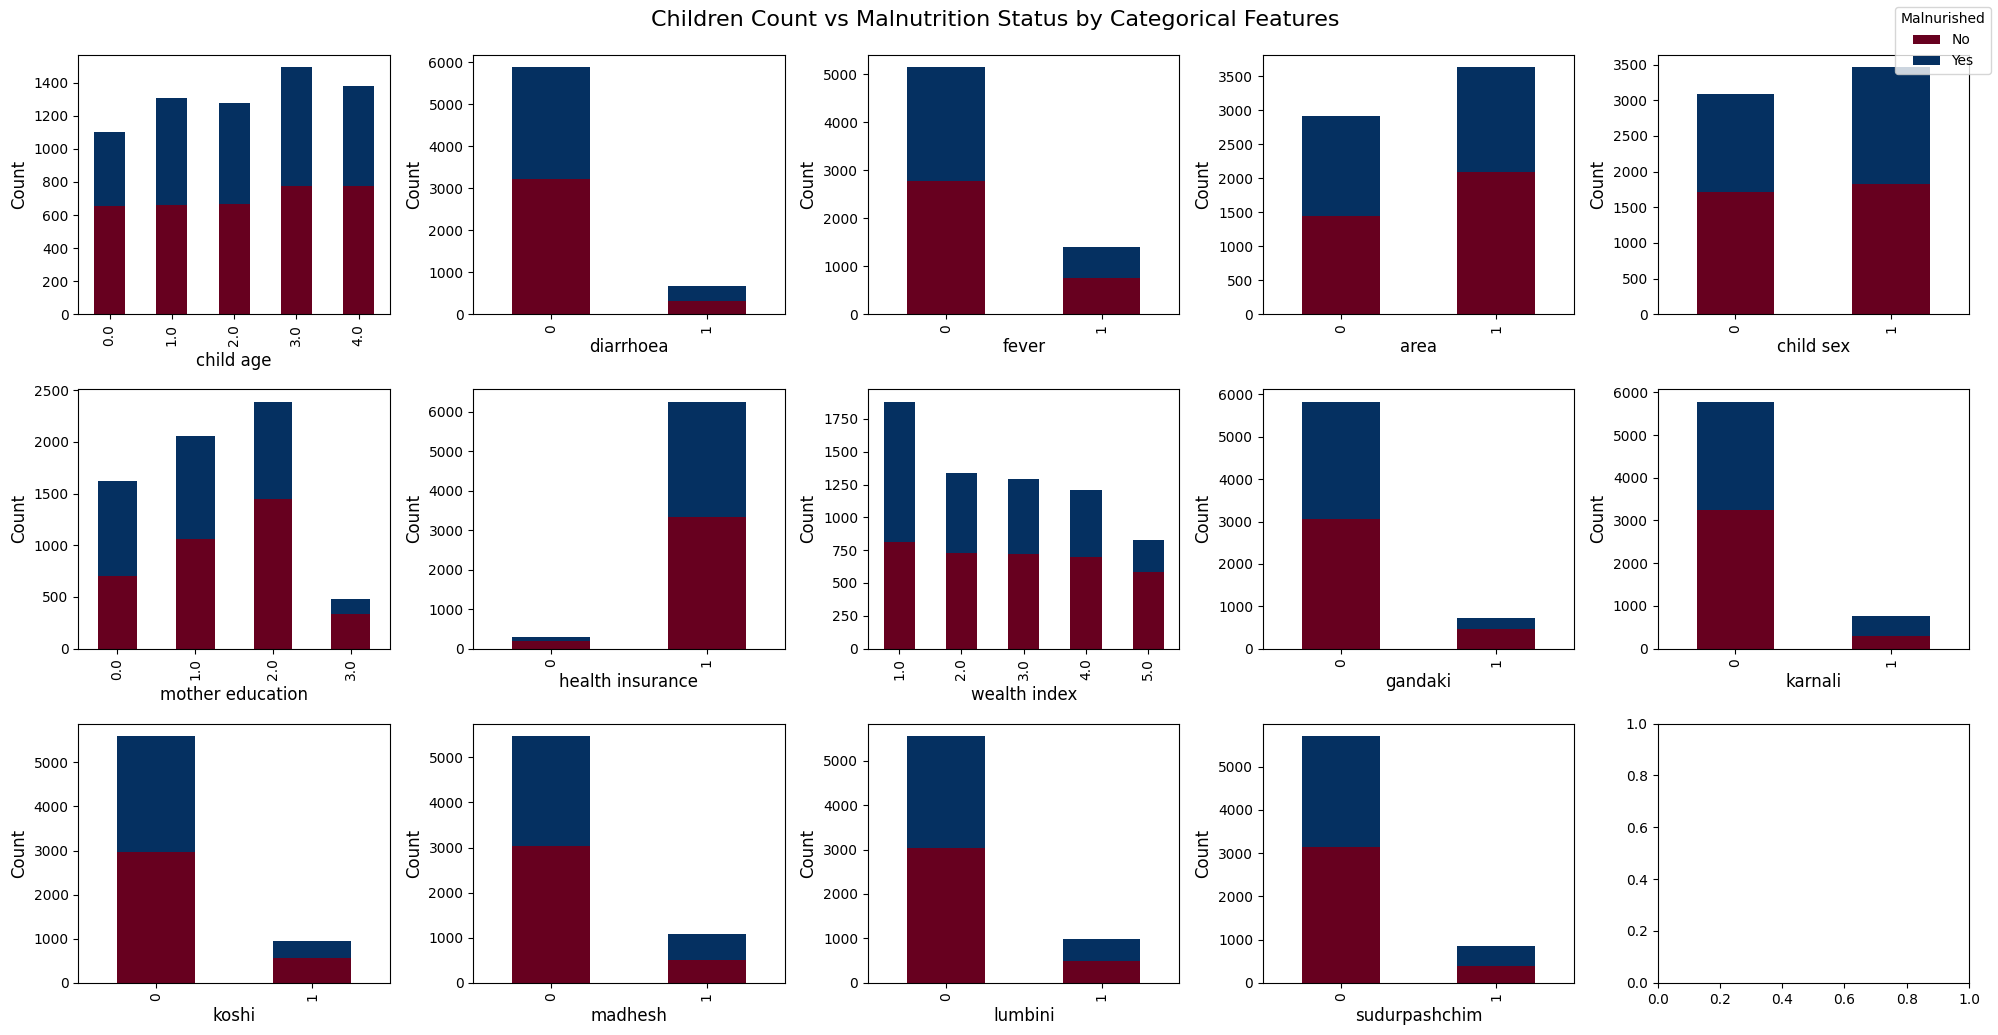

In [155]:
# List of features to plot
features = [
    'child age', 'diarrhoea', 'fever', 'area', 'child sex', 'mother education', 'health insurance', 'wealth index', 'gandaki', 'karnali', 'koshi',	'madhesh',	'lumbini',	'sudurpashchim'
]

# Set up a grid for 2 rows × 4 columns
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(20, 10))

# Flatten axes for easy iteration
axes = axes.flatten()

for i, feature in enumerate(features):
    ctab = pd.crosstab(df[feature], df['status'])
    ctab.plot(kind='bar', stacked=True, colormap='RdBu', ax=axes[i], legend=False)
    axes[i].set_ylabel("Count", fontsize=12)
    axes[i].set_xlabel(feature, fontsize=12)

# Add one global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['No', 'Yes'], title='Malnurished', loc='upper right')

plt.tight_layout()
plt.suptitle("Children Count vs Malnutrition Status by Categorical Features", fontsize=16, y=1.03)
plt.show()

## Feature Importance Check for Categorical Features

### Contingency table for categorical features

In [157]:
vc = df['child age'].value_counts()
vc_pct = df['child age'].value_counts(normalize=True) * 100

summary = vc.astype(str) + " (" + vc_pct.round(2).astype(str) + ")"
print(summary)

child age
3.0    1492 (22.77)
4.0    1380 (21.06)
1.0     1304 (19.9)
2.0    1276 (19.47)
0.0    1100 (16.79)
dtype: object


In [158]:
# Listing all categorical features
cat_columns = [
    'child age', 'diarrhoea', 'fever', 'area', 'child sex', 'mother education', 'health insurance', 'wealth index', 'gandaki', 'karnali', 'koshi',	'madhesh',	'lumbini',	'sudurpashchim'
]

# Contingency table for categorical features
for col in cat_columns:
    table = pd.crosstab(df[col], df['status'], margins=False)

    # Calculate row-wise percentages
    row_pct = table.div(table.sum(axis=1), axis=0) * 100
    row_pct = row_pct.round(1)  # Round to 1 decimal

    # Combine count and percentage for pretty output
    combined = table.astype(str) + " (" + row_pct.astype(str) + ")"

    print(f"\nContingency table for {col}:\n{combined}\n")



Contingency table for child age:
status              0           1
child age                        
0.0        657 (59.7)  443 (40.3)
1.0        662 (50.8)  642 (49.2)
2.0        666 (52.2)  610 (47.8)
3.0        777 (52.1)  715 (47.9)
4.0        773 (56.0)  607 (44.0)


Contingency table for diarrhoea:
status               0            1
diarrhoea                          
0          3210 (54.6)  2667 (45.4)
1           325 (48.1)   350 (51.9)


Contingency table for fever:
status            0            1
fever                           
0       2788 (54.2)  2360 (45.8)
1        747 (53.2)   657 (46.8)


Contingency table for area:
status            0            1
area                            
0       1445 (49.5)  1476 (50.5)
1       2090 (57.6)  1541 (42.4)


Contingency table for child sex:
status               0            1
child sex                          
0          1711 (55.4)  1379 (44.6)
1          1824 (52.7)  1638 (47.3)


Contingency table for mother education:
sta

In [159]:
X_cat = df[cat_columns].copy()
y = df['status']

# # Label encode all categorical variables if needed
# for col in X_cat.columns:
#     if X_cat[col].dtype == 'object':
#         X_cat[col] = LabelEncoder().fit_transform(X_cat[col])

chi_vals, p_vals = chi2(X_cat, y)

chi_df = pd.DataFrame({'Feature': X_cat.columns, 'Chi2': chi_vals, 'p-value': p_vals})
print(chi_df.sort_values(by='Chi2', ascending=False))


             Feature        Chi2       p-value
7       wealth index  121.289475  3.302509e-28
5   mother education  107.392252  3.652316e-25
9            karnali   69.661074  7.042223e-17
8            gandaki   38.085818  6.770041e-10
13     sudurpashchim   23.278844  1.401330e-06
11           madhesh   23.068611  1.563220e-06
3               area   19.014275  1.297442e-05
10             koshi   15.701375  7.417024e-05
1          diarrhoea    9.155200  2.480123e-03
12           lumbini    5.488034  1.914706e-02
4          child sex    2.235867  1.348410e-01
6   health insurance    1.163027  2.808386e-01
0          child age    0.929861  3.348991e-01
2              fever    0.316078  5.739741e-01


### Cramer's V Test
$
V = \sqrt{ \frac{\chi^2 / n}{\min(k - 1, r - 1)} }
$

In [160]:
cramers_v_results = {}

for col in cat_columns:
    if col != 'status':
        table = pd.crosstab(df[col], df['status'])
        chi2, _, _, _ = chi2_contingency(table)
        n = table.sum().sum()
        phi2 = chi2 / n
        r, k = table.shape
        dof = min(k - 1, r - 1)
        V = np.sqrt(phi2 / dof)

        cramers_v_results[col] = V
        # print(f"{col}: Cramér's V = {V:.4f}")

cramers_v_sorted = pd.Series(cramers_v_results).sort_values(ascending=False)
print(cramers_v_sorted)

wealth index        0.168761
mother education    0.157582
karnali             0.109288
area                0.080374
gandaki             0.080322
madhesh             0.064480
sudurpashchim       0.063399
child age           0.063178
health insurance    0.062584
koshi               0.052512
diarrhoea           0.038965
lumbini             0.030999
child sex           0.026593
fever               0.007463
dtype: float64


In [161]:
# Plotting the sorted Cramér's V values
plt.figure(figsize=(10, 6))
cramers_v_sorted.plot(kind='barh')

plt.title("Cramér's V Association with Malnutrition", fontsize=14)
plt.xlabel("Cramér's V", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.gca().invert_yaxis()  # Highest at the top
plt.grid(False)
plt.tight_layout()
plt.show()

## Data visualization

In [162]:
# Encode and scale the dataset
X = pd.get_dummies(df.drop(columns='status'), drop_first=True)
y = df['status']
X_scaled = StandardScaler().fit_transform(X)

# Reduce with PCA (3D)
X_pca = PCA(n_components=3).fit_transform(X_scaled)

# Reduce with t-SNE (3D)
X_tsne = TSNE(n_components=3, random_state=42).fit_transform(X_scaled)

# Reduce with UMAP (3D)
X_umap = umap.UMAP(n_components=3, random_state=42).fit_transform(X_scaled)

# Plot
fig = plt.figure(figsize=(15, 7))

# PCA
ax1 = fig.add_subplot(131, projection='3d')
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y, cmap='Set1', s=10)
ax1.set_title("PCA")
ax1.set_xlabel("Component 1")
ax1.set_ylabel("Component 2")
ax1.set_zlabel("Component 3")

# t-SNE
ax2 = fig.add_subplot(132, projection='3d')
scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2], c=y, cmap='Set1', s=10)
ax2.set_title("t-SNE")
ax2.set_xlabel("Component 1")
ax2.set_ylabel("Component 2")
ax2.set_zlabel("Component 3")

# UMAP
ax3 = fig.add_subplot(133, projection='3d')
scatter3 = ax3.scatter(X_umap[:, 0], X_umap[:, 1], X_umap[:, 2], c=y, cmap='Set1', s=10)
ax3.set_title("UMAP")
ax3.set_xlabel("Component 1")
ax3.set_ylabel("Component 2")
ax3.set_zlabel("Component 3")

# Legend (common)
fig.legend(*scatter1.legend_elements(), title="Malnourished", loc="upper right")
# fig.suptitle("3D PCA vs t-SNE vs UMAP Projection of Dataset", fontsize=16)
plt.tight_layout()
plt.show()

## Save final data

In [22]:
# df.to_csv(r'C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv', index=False)

---

## Boruta Algorithm for feature selection

In [163]:
# Separate features and target
X = df.drop(columns='status')
y = df['status']

# Convert to numpy arrays (Boruta requires numpy arrays)
X_np = X.values
y_np = y.values

# Define the RandomForest model for Boruta
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)

# Initialize Boruta
boruta_selector = BorutaPy(
    estimator=rf,
    n_estimators='auto',
    verbose=2,
    random_state=42
)

# Fit Boruta
boruta_selector.fit(X_np, y_np)

In [164]:

# Get selected feature names
selected_features = X.columns[boruta_selector.support_].tolist()
print("Selected Features by Boruta:")
print(selected_features)

_______

In [165]:
# Get feature rankings for all features
feature_ranks = pd.DataFrame({
    'Feature': X.columns,
    'Rank': boruta_selector.ranking_
}).sort_values(by='Rank')

print(feature_ranks)


## Provincewise status

### From our dataset

In [26]:
# Compute percentages of stunting, underweight, and wasting by province from the dataset
province_wise = (
    df2.groupby('province', observed=True)[['stunting', 'underweight', 'wasting', 'status']]
    .mean()
    .multiply(100)
    .reset_index()
    .rename(columns={'stunting': 'stunting %',
                     'underweight': 'underweight %',                     
                     'wasting': 'wasting %',
                     'status': 'status %'})
).round(2)
province_wise

# province_wise.to_csv(r'C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\provincewise percentage.csv', index=False) #Export to csv

In [27]:
import geopandas as gpd

# Step 1: Load GeoJSON and prepare data
gdf = gpd.read_file(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\nepal_admin1.geojson")  # name of downloaded file
gdf = gdf.rename(columns={"name": "province"})

# Step 2: Your data
data = {
    'province': ['Province No. 1', 'Province No. 2', 'Bagmati', 'Gandaki',
                 'Lumbini', 'Karnali', 'Sudurpashchim'],
    'Stunting': [28.39, 41.34, 27.69, 26.11, 37.09, 48.31, 42.94],
    'Underweight': [20.08, 29.61, 14.26, 15.42, 29.85, 35.97, 33.69],
    'Wasting': [14.72, 22.63, 9.92, 10.97, 15.68, 21.56, 17.32],
    'Status': [39.64, 53.35, 32.94, 34.58, 49.75, 61.04, 54.33]
}
df_data = pd.DataFrame(data)

# Step 3: Merge with geodata
merged = gdf.merge(df_data, on='province')

# Step 4: Create 2x2 plot grid
fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)

cols = ['Stunting', 'Underweight', 'Wasting', 'Status']
cmaps = ['Blues', 'Greens', 'Purples', 'Oranges']
titles = ['Stunting', 'Underweight', 'Wasting', 'Overall Status']

# Flatten the axes for easy iteration
axes = axes.flatten()

for ax, col, cmap, title in zip(axes, cols, cmaps, titles):
    merged.plot(
        column=col, cmap=cmap, linewidth=0.6,
        edgecolor='gray', legend=True, ax=ax
    )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

# Step 5: Add province names at centroids
for idx, row in merged.iterrows():
    centroid = row['geometry'].centroid
    for ax in axes:
        ax.text(centroid.x, centroid.y, row['province'], fontsize=8,
                ha='center', va='center', color='black')

plt.show()


## Percentage of children who are malnourished

In [28]:
malnourished_cols = ['stunting', 'underweight', 'wasting', 'status']
percent_malnourished = (df2[malnourished_cols].mean() * 100).round(2)
print(percent_malnourished)